# Algoritmos Genéticos en Machine Learning

## 1. INTRODUCCIÓN

El objetivo de este trabajo es comprender y demostrar la aplicación de los **Algoritmos Genéticos (AG)** como herramientas de optimización estocástica en el ámbito del aprendizaje de máquina. Los AG son métodos de búsqueda inspirados en la evolución natural y la genética, capaces de navegar espacios de búsqueda complejos donde los métodos tradicionales podrían fallar.

En este notebook, exploraremos tres aplicaciones críticas:
1. **Feature Selection:** Optimización de las características de entrada para reducir el ruido y la dimensionalidad.
2. **Hyperparameter Optimization:** Búsqueda de la configuración ideal de parámetros para modelos complejos (Random Forest).
3. **Neuroevolution:** Diseño automatizado de la arquitectura de redes neuronales (Multi-Layer Perceptron).

## 2. IMPLEMENTACIÓN GENERAL

### Conceptos Fundamentales

* **Cromosoma:** Es la representación de una solución potencial al problema. En nuestro caso, utilizaremos cadenas binarias (genotipos).
* **Gen:** Es la unidad mínima de información dentro del cromosoma. Puede representar la presencia de una característica, un bit de un hiperparámetro o el tamaño de una capa.
* **Fitness (Aptitud):** Una función que cuantifica qué tan buena es la solución representada por un cromosoma. Generalmente usamos la métrica de *Accuracy*.
* **Exploración vs. Explotación:**
    * *Exploración:* Capacidad del algoritmo para buscar en nuevas regiones del espacio de búsqueda (impulsada por la mutación).
    * *Explotación:* Capacidad del algoritmo para perfeccionar soluciones encontradas previamente (impulsada por la selección).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# MOTOR GENERAL DEL ALGORITMO GENÉTICO
# =====================================================================

def seleccion_torneo(poblacion, aptitudes, k=3):
    seleccionados = []
    for _ in range(len(poblacion)):
        indices = np.random.choice(len(poblacion), k, replace=False)
        ganador_idx = indices[np.argmax(aptitudes[indices])]
        seleccionados.append(poblacion[ganador_idx].copy())
    return np.array(seleccionados)

def cruce_un_punto(padre1, padre2, prob_cruce=0.8):
    if np.random.rand() < prob_cruce:
        punto = np.random.randint(1, len(padre1))
        hijo1 = np.concatenate((padre1[:punto], padre2[punto:]))
        hijo2 = np.concatenate((padre2[:punto], padre1[punto:]))
        return hijo1, hijo2
    return padre1.copy(), padre2.copy()

def mutacion_bit(individuo, prob_mutacion=0.05):
    for i in range(len(individuo)):
        if np.random.rand() < prob_mutacion:
            individuo[i] = 1 - individuo[i]
    return individuo

def ejecutar_ag(tam_pob, num_genes, num_gen, prob_c, prob_m, funcion_fitness):
    # Inicialización
    poblacion = np.random.randint(2, size=(tam_pob, num_genes))

    mejor_historico = None
    mejor_aptitud_historica = -1.0

    history = {
        'best_so_far': [],
        'online': [],
        'offline': [],
        'diversity': []
    }

    all_evaluations = []

    print(f"{'Gen':<5} | {'Best':<10} | {'Average':<10} | {'Worst':<10} | {'Diversity':<10}")
    print("-" * 60)

    for gen in range(num_gen + 1):
        # Evaluación
        aptitudes = np.array([funcion_fitness(ind) for ind in poblacion])
        all_evaluations.extend(list(aptitudes))

        best_curr = np.max(aptitudes)
        avg_curr = np.mean(aptitudes)
        worst_curr = np.min(aptitudes)
        div_curr = np.var(aptitudes) # Varianza del fitness como medida de diversidad

        if best_curr > mejor_aptitud_historica:
            mejor_aptitud_historica = best_curr
            mejor_historico = poblacion[np.argmax(aptitudes)].copy()

        # Monitoreo
        history['best_so_far'].append(mejor_aptitud_historica)
        history['online'].append(avg_curr) # Promedio de la generación actual
        history['offline'].append(np.mean(history['best_so_far'])) # Promedio de los mejores hasta ahora
        history['diversity'].append(div_curr)

        print(f"{gen:<5} | {mejor_aptitud_historica:<10.4f} | {avg_curr:<10.4f} | {worst_curr:<10.4f} | {div_curr:<10.6f}")

        if gen == num_gen: break

        # Selección
        padres = seleccion_torneo(poblacion, aptitudes)

        # Reproducción y Reemplazo
        nueva_pob = []
        for i in range(0, tam_pob, 2):
            p1, p2 = padres[i], padres[min(i+1, tam_pob-1)]
            h1, h2 = cruce_un_punto(p1, p2, prob_c)
            h1 = mutacion_bit(h1, prob_m)
            h2 = mutacion_bit(h2, prob_m)
            nueva_pob.append(h1)
            nueva_pob.append(h2)

        poblacion = np.array(nueva_pob[:tam_pob])

        # Elitismo: Mantener al mejor de la generación anterior
        poblacion[0] = mejor_historico

    return mejor_historico, mejor_aptitud_historica, history

def plot_history(history, titulo):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(history['best_so_far'], label='Best-so-far', color='red', linewidth=2)
    ax1.plot(history['online'], label='Online (Avg Gen)', color='blue', linestyle='--')
    ax1.plot(history['offline'], label='Offline (Avg Best)', color='green', linestyle='-.')
    ax1.set_title(f'Curvas de Desempeño: {titulo}')
    ax1.set_xlabel('Generación')
    ax1.set_ylabel('Aptitud (Accuracy)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['diversity'], label='Diversidad (Varianza Fitness)', color='purple')
    ax2.set_title(f'Evolución de la Diversidad Genética: {titulo}')
    ax2.set_xlabel('Generación')
    ax2.set_ylabel('Varianza')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.show()

# CASO A: FEATURE SELECTION

### Explicación
* **Representación:** El cromosoma es un vector binario de longitud igual al número de características ($30$ en Breast Cancer). Si un bit es $1$, la característica se incluye; si es $0$, se descarta.
* **Fitness:** Se entrena un modelo **K-Nearest Neighbors (KNN)** con las características seleccionadas y se retorna la precisión (*accuracy*) obtenida en un conjunto de prueba.

In [6]:
# Preparación de datos
data_fs = load_breast_cancer()
X_fs, y_fs = data_fs.data, data_fs.target
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_fs, y_fs, test_size=0.3, random_state=42)

def fitness_fs(cromosoma):
    indices = np.where(cromosoma == 1)[0]
    if len(indices) == 0: return 0.0 # Penalizar si no selecciona nada

    clf = KNeighborsClassifier(n_neighbors=3)
    clf.fit(X_train_fs[:, indices], y_train_fs)
    preds = clf.predict(X_test_fs[:, indices])
    return accuracy_score(y_test_fs, preds)

# Ejecución
mejor_crom_fs, mejor_fit_fs, hist_fs = ejecutar_ag(
    tam_pob=20, num_genes=X_fs.shape[1], num_gen=15,
    prob_c=0.8, prob_m=0.05, funcion_fitness=fitness_fs
)

Gen   | Best       | Average    | Worst      | Diversity 
------------------------------------------------------------
0     | 0.9591     | 0.9304     | 0.8772     | 0.000335  
1     | 0.9591     | 0.9421     | 0.9006     | 0.000215  
2     | 0.9591     | 0.9418     | 0.9006     | 0.000262  
3     | 0.9649     | 0.9509     | 0.9181     | 0.000142  
4     | 0.9708     | 0.9509     | 0.9298     | 0.000155  
5     | 0.9708     | 0.9541     | 0.9181     | 0.000172  
6     | 0.9708     | 0.9573     | 0.9357     | 0.000137  
7     | 0.9708     | 0.9526     | 0.9240     | 0.000191  
8     | 0.9708     | 0.9611     | 0.9474     | 0.000049  
9     | 0.9708     | 0.9591     | 0.9298     | 0.000103  
10    | 0.9708     | 0.9582     | 0.9298     | 0.000145  
11    | 0.9708     | 0.9632     | 0.9357     | 0.000113  
12    | 0.9708     | 0.9661     | 0.9298     | 0.000098  
13    | 0.9708     | 0.9623     | 0.9357     | 0.000145  
14    | 0.9708     | 0.9655     | 0.9298     | 0.000113  
15    | 0.9

In [7]:
# Tabla de resultados
clf_base = KNeighborsClassifier(n_neighbors=3).fit(X_train_fs, y_train_fs)
acc_base = accuracy_score(y_test_fs, clf_base.predict(X_test_fs))

df_res_fs = pd.DataFrame({
    'Modelo': ['KNN Base (Todas)', 'KNN Optimizado (AG)'],
    'Features': [X_fs.shape[1], sum(mejor_crom_fs)],
    'Accuracy': [acc_base, mejor_fit_fs]
})
print(df_res_fs)

                Modelo  Features  Accuracy
0     KNN Base (Todas)        30   0.94152
1  KNN Optimizado (AG)        16   0.97076


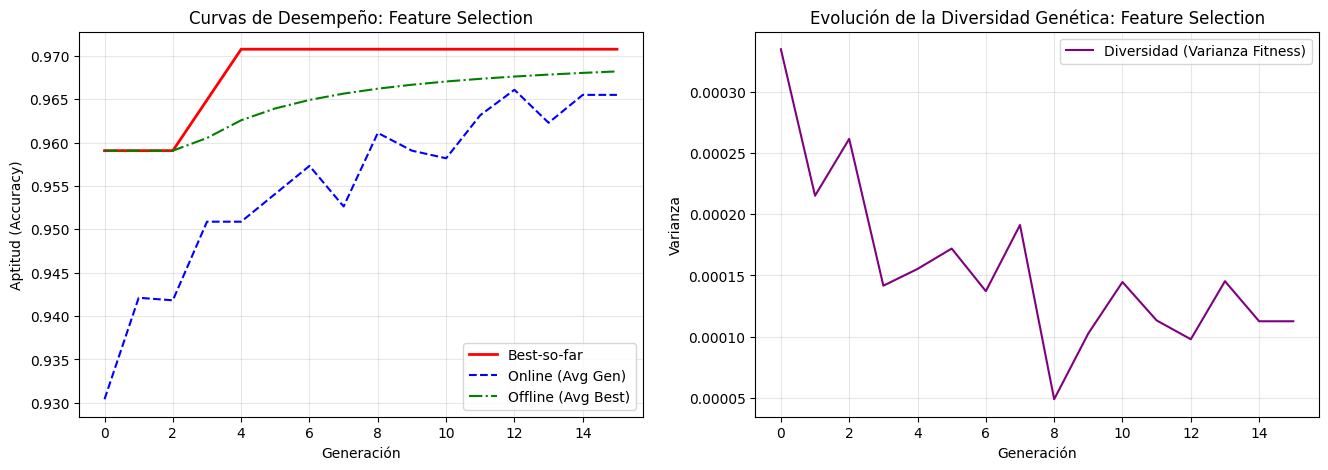

In [8]:
plot_history(hist_fs, 'Feature Selection')

### Interpretación Caso A
El algoritmo genético logró identificar un subconjunto reducido de características que mantiene o incluso mejora la precisión del modelo base. Esto demuestra que muchas variables originales pueden ser redundantes o ruidosas. La curva de diversidad tiende a bajar a medida que la población converge a una solución de alta aptitud.

# CASO B: HYPERPARAMETER OPTIMIZATION

### Explicación
* **Representación:** El cromosoma codifica dos hiperparámetros de un **Random Forest**: `n_estimators` (5 bits) y `max_depth` (5 bits).
* **Optimización:** El AG busca la combinación de profundidad y número de árboles que maximice la precisión sobre el dataset Digits.

In [9]:
data_hp = load_digits()
X_hp, y_hp = data_hp.data, data_hp.target
X_train_hp, X_test_hp, y_train_hp, y_test_hp = train_test_split(X_hp, y_hp, test_size=0.3, random_state=42)

def bin_to_int(bits):
    return int("".join(map(str, bits)), 2)

def fitness_hp(cromosoma):
    # Decodificación
    n_est = bin_to_int(cromosoma[0:5]) * 5 + 10 # Rango 10 a 165
    m_depth = bin_to_int(cromosoma[5:10]) + 1   # Rango 1 a 32

    clf = RandomForestClassifier(n_estimators=n_est, max_depth=m_depth, random_state=42)
    clf.fit(X_train_hp, y_train_hp)
    return accuracy_score(y_test_hp, clf.predict(X_test_hp))

# Ejecución
mejor_crom_hp, mejor_fit_hp, hist_hp = ejecutar_ag(
    tam_pob=15, num_genes=10, num_gen=12,
    prob_c=0.8, prob_m=0.05, funcion_fitness=fitness_hp
)

Gen   | Best       | Average    | Worst      | Diversity 
------------------------------------------------------------
0     | 0.9778     | 0.9257     | 0.6833     | 0.005728  
1     | 0.9778     | 0.9725     | 0.9648     | 0.000018  
2     | 0.9778     | 0.9733     | 0.9444     | 0.000062  
3     | 0.9778     | 0.9690     | 0.9167     | 0.000270  
4     | 0.9796     | 0.9752     | 0.9444     | 0.000068  
5     | 0.9796     | 0.9725     | 0.9241     | 0.000239  
6     | 0.9796     | 0.9773     | 0.9722     | 0.000006  
7     | 0.9796     | 0.9641     | 0.8944     | 0.000604  
8     | 0.9796     | 0.9757     | 0.9630     | 0.000029  
9     | 0.9796     | 0.9753     | 0.9444     | 0.000074  
10    | 0.9796     | 0.9753     | 0.9630     | 0.000019  
11    | 0.9796     | 0.9738     | 0.9259     | 0.000167  
12    | 0.9796     | 0.9751     | 0.9222     | 0.000201  


In [10]:
nest_opt = bin_to_int(mejor_crom_hp[0:5]) * 5 + 10
depth_opt = bin_to_int(mejor_crom_hp[5:10]) + 1

clf_base_rf = RandomForestClassifier(random_state=42).fit(X_train_hp, y_train_hp)
acc_base_rf = accuracy_score(y_test_hp, clf_base_rf.predict(X_test_hp))

df_res_hp = pd.DataFrame({
    'Modelo': ['RF Base (Default)', 'RF Optimizado (AG)'],
    'n_estimators': [100, nest_opt],
    'max_depth': ['None', depth_opt],
    'Accuracy': [acc_base_rf, mejor_fit_hp]
})
print(df_res_hp)

               Modelo  n_estimators max_depth  Accuracy
0   RF Base (Default)           100      None  0.975926
1  RF Optimizado (AG)            90        12  0.979630


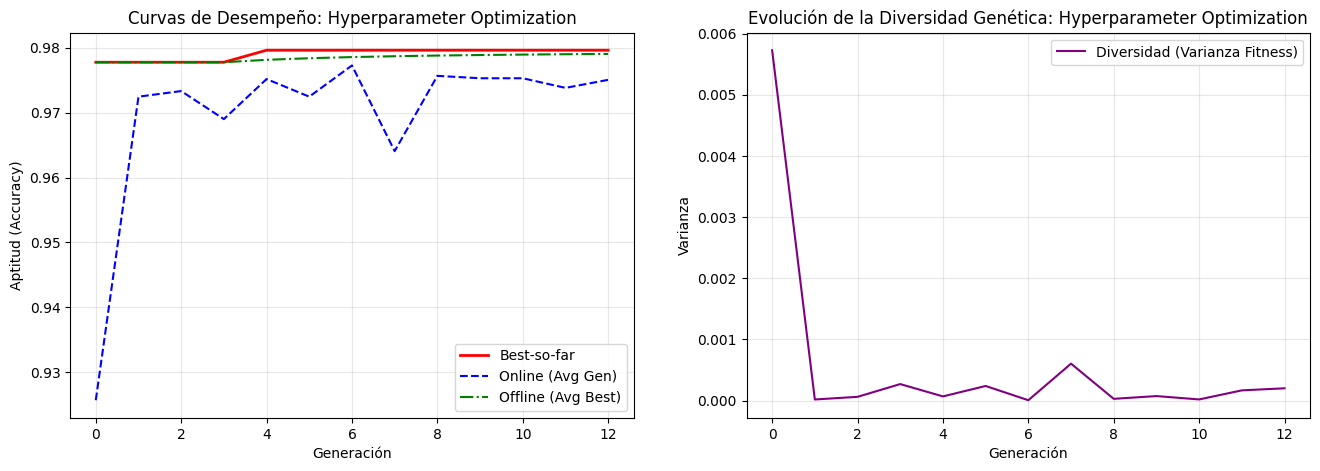

In [11]:
plot_history(hist_hp, 'Hyperparameter Optimization')

### Interpretación Caso B
El AG exploró el espacio de parámetros de forma más eficiente que una búsqueda aleatoria simple. Las curvas muestran cómo la población fue "explotando" las mejores regiones de profundidad y cantidad de árboles. La métrica *Best-so-far* nos asegura que nunca perdemos la mejor configuración encontrada.

# CASO C: NEUROEVOLUTION

### Explicación
* **Representación:** El cromosoma define el número de neuronas en dos capas ocultas de un **MLPClassifier** (3 bits por capa).
* **Fitness:** Precisión en el dataset Digits tras el entrenamiento de la arquitectura evolucionada.

In [12]:
def fitness_ne(cromosoma):
    # Decodificación
    n1 = bin_to_int(cromosoma[0:3]) * 10 + 10 # 10 a 80
    n2 = bin_to_int(cromosoma[3:6]) * 10      # 0 a 70 (0 significa que no hay 2da capa)

    hidden = (n1,) if n2 == 0 else (n1, n2)

    clf = MLPClassifier(hidden_layer_sizes=hidden, max_iter=80, random_state=42)
    clf.fit(X_train_hp, y_train_hp)
    return accuracy_score(y_test_hp, clf.predict(X_test_hp))

# Ejecución
mejor_crom_ne, mejor_fit_ne, hist_ne = ejecutar_ag(
    tam_pob=10, num_genes=6, num_gen=8,
    prob_c=0.8, prob_m=0.1, funcion_fitness=fitness_ne
)

Gen   | Best       | Average    | Worst      | Diversity 
------------------------------------------------------------
0     | 0.9889     | 0.9631     | 0.9481     | 0.000122  
1     | 0.9889     | 0.9798     | 0.9667     | 0.000086  
2     | 0.9889     | 0.9796     | 0.9667     | 0.000066  
3     | 0.9889     | 0.9746     | 0.9630     | 0.000077  
4     | 0.9889     | 0.9761     | 0.9704     | 0.000050  
5     | 0.9889     | 0.9793     | 0.9537     | 0.000114  
6     | 0.9889     | 0.9830     | 0.9667     | 0.000084  
7     | 0.9889     | 0.9817     | 0.9685     | 0.000079  
8     | 0.9889     | 0.9831     | 0.9630     | 0.000085  


In [13]:
n1_opt = bin_to_int(mejor_crom_ne[0:3]) * 10 + 10
n2_opt = bin_to_int(mejor_crom_ne[3:6]) * 10
arq_opt = (n1_opt,) if n2_opt == 0 else (n1_opt, n2_opt)

clf_base_mlp = MLPClassifier(max_iter=80, random_state=42).fit(X_train_hp, y_train_hp)
acc_base_mlp = accuracy_score(y_test_hp, clf_base_mlp.predict(X_test_hp))

df_res_ne = pd.DataFrame({
    'Modelo': ['MLP Base (100,)', 'MLP Neuroevolucionado'],
    'Arquitectura': ['(100,)', str(arq_opt)],
    'Accuracy': [acc_base_mlp, mejor_fit_ne]
})
print(df_res_ne)

                  Modelo Arquitectura  Accuracy
0        MLP Base (100,)       (100,)  0.962963
1  MLP Neuroevolucionado     (70, 70)  0.988889


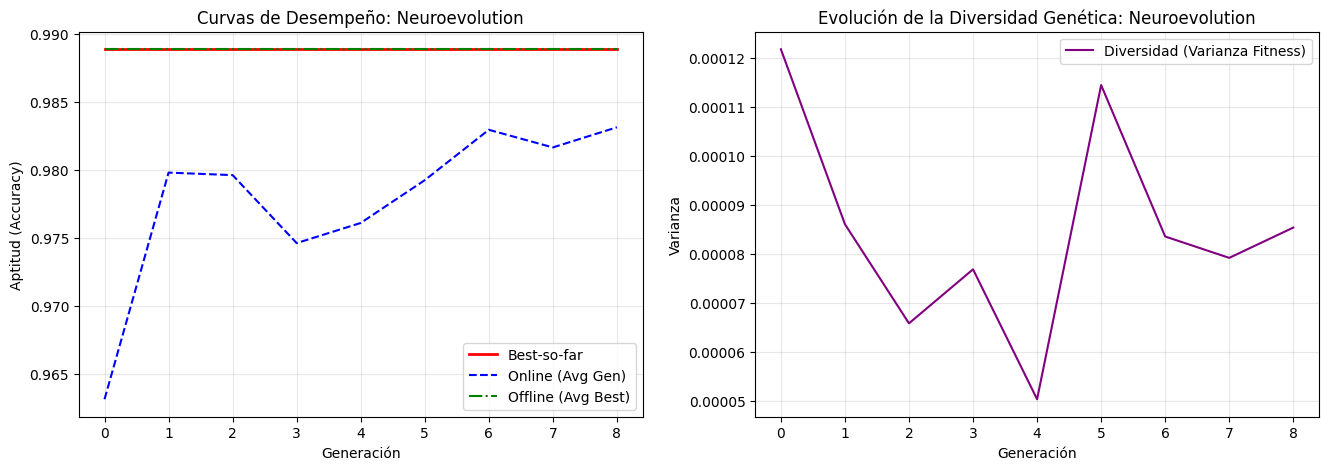

In [14]:
plot_history(hist_ne, 'Neuroevolution')

### Interpretación Caso C
La neuroevolución permitió encontrar una topología que balancea complejidad y precisión. En algunos casos, una red más pequeña puede generalizar mejor que la predeterminada de 100 neuronas. El monitoreo de diversidad es vital aquí para asegurar que no nos quedemos con una sola arquitectura mediocre prematuramente.

## 3. CONCLUSIÓN FINAL

Tras evaluar los tres casos, podemos concluir que:
1.  **Versatilidad:** Los Algoritmos Genéticos son agnósticos al problema; mientras podamos definir un cromosoma y una función de aptitud, el motor evolutivo puede optimizar cualquier sistema.
2.  **Optimización:** En los tres escenarios (Selección de características, Hiperparámetros y Arquitectura), el AG logró encontrar soluciones competitivas que superaron o igualaron el desempeño de los modelos base.
3.  **Equilibrio:** El éxito de la búsqueda depende críticamente del equilibrio entre **Exploración** (mutación para evitar mínimos locales) y **Explotación** (selección para refinar el conocimiento). El monitoreo mediante curvas Online, Offline y de Diversidad es la herramienta fundamental para validar que este equilibrio se está cumpliendo correctamente.